In [1]:
import pandas as pd

# Read the file, skipping comment lines that start with '#'
df = pd.read_csv(
    "etmgeg_240 copy 2.txt",
    comment='#',
    header=None,
    sep=",",
    engine="python"
)

# Manually set the column names (from the KNMI description)
cols = [
    "STN","YYYYMMDD","DDVEC","FHVEC","FG","FHX","FHXH","FHN","FHNH",
    "FXX","FXXH","TG","TN","TNH","TX","TXH","T10N","T10NH","SQ","SP",
    "Q","DR","RH","RHX","RHXH","PG","PX","PXH","PN","PNH","VVN","VVNH",
    "VVX","VVXH","NG","UG","UX","UXH","UN","UNH","EV24"
]
df.columns = cols

df["date"] = pd.to_datetime(df["YYYYMMDD"], format="%Y%m%d")

pd.read_csv(...) opens a file and loads it into a DataFrame which is a table of rows and columns. 
comment='#' - any line in the file starting with # is ignored.
header=None - tells panda that the file has no column name. 
sep="," - tells pandas values are separated by commas
engine="python" - uses Python's own CSV parser, which handles edge cases more flexibly than the default C parser
https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html

cols = - "header = None" makes panda assign numbers as names for the columns. df.columns = cols changes the name of the columns. 

df["YYYYMMDD"] - selects the column named YYYYMMDD, which holds dates stored as plain integers like 20231015
pd.to_datetime(..., format="%Y%m%d") — converts those integers into proper Python date objects. the format string %Y%m%d tells pandas the layout
df["date"] = ... — creates a new column called date in the DataFrame and stores the converted dates there


In [2]:
import numpy as np

df["PG_hPa"] = df["PG"] / 10.0
df["RH_mm"]  = df["RH"] / 10.0

df["NG"] = df["NG"].astype(str).str.strip()
df["NG"] = pd.to_numeric(df["NG"], errors="coerce")
df["VVN"] = df["VVN"].astype(str).str.strip()
df["VVN"] = pd.to_numeric(df["VVN"], errors="coerce")

# changing degrees to x and y components for wind direction:
df["DDVEC_sin"] = np.sin(np.radians(df["DDVEC"]))
df["DDVEC_cos"] = np.cos(np.radians(df["DDVEC"]))
#df.drop(columns=['DDVEC'], inplace=True)

# change of features:

df["dNG"]           = df["NG"].diff()
df["dUG"]           = df["UG"].diff()
df["dPG_hPa"]       = df["PG_hPa"].diff()
df["dRH_mm"]        = df["RH_mm"].diff()
df["dFG"]           = df["FG"].diff()
df["dDDVEC_sin"]    = df["DDVEC_sin"].diff()
df["dDDVEC_cos"]    = df["DDVEC_cos"].diff()
df["dVVN"]          = df["VVN"].diff()
df["dTG"]           = df["TG"].diff()
df["dSQ"]           = df["SQ"].diff()

#define the feature data frame and drop nan rows from df features
df_features = df.dropna(subset=["dRH_mm","dNG","dUG","dPG_hPa","dFG","dDDVEC_sin","dDDVEC_cos","dVVN","dTG","dSQ"])[[
    "date",
    "RH_mm","NG","UG","PG_hPa","FG","DDVEC_sin","DDVEC_cos","VVN","TG","SQ",      # levels
    "dRH_mm","dNG","dUG","dPG_hPa","dFG","dDDVEC_sin","dDDVEC_cos","dVVN","dTG","dSQ"   # changes
]]

#print(df_features)

.astype(str) — converts every value to a string (text), even if it was already a number
.str.strip() — removes invisible whitespace characters (spaces, tabs) from both ends of each value
pd.to_numeric(..., errors="coerce") — converts the cleaned strings back to numbers; if a value can't be converted (e.g., a dash - or empty string), it becomes NaN (pandas' version of "missing") instead of crashing

.dropna(subset=[...]) — drops any row where any of the listed columns is NaN

In [3]:
print(df_features.corr())

                date     RH_mm        NG        UG    PG_hPa        FG  \
date        1.000000  0.036321  0.098658 -0.166676 -0.010324 -0.039356   
RH_mm       0.036321  1.000000  0.297130  0.249387 -0.404428  0.275896   
NG          0.098658  0.297130  1.000000  0.525066 -0.309337  0.227888   
UG         -0.166676  0.249387  0.525066  1.000000 -0.148132 -0.009327   
PG_hPa     -0.010324 -0.404428 -0.309337 -0.148132  1.000000 -0.394888   
FG         -0.039356  0.275896  0.227888 -0.009327 -0.394888  1.000000   
DDVEC_sin   0.000932 -0.197882 -0.271833 -0.184770  0.140027 -0.253674   
DDVEC_cos  -0.038583 -0.129496 -0.219641 -0.236555  0.279146 -0.199234   
VVN         0.187206 -0.100945 -0.198182 -0.570043 -0.015013  0.208579   
TG          0.108475  0.034696 -0.136669 -0.359798 -0.030060 -0.118930   
SQ          0.093943 -0.281151 -0.780338 -0.706943  0.265258 -0.231327   
dRH_mm     -0.000220  0.618045  0.134783  0.117927 -0.097652  0.070235   
dNG        -0.000043  0.122706  0.4963

**Bellow are Pearson correlations of today's features with tomorrow's rain.**





In [4]:
# Tomorrow's rain
df_features["RH_mm_tomorrow"] = df_features["RH_mm"].shift(-1)

# Drop last row (no tomorrow)
df_features = df_features.dropna(subset=["RH_mm_tomorrow"])

# Correlate today's predictors with tomorrow's rain
predictors = ["NG","UG","PG_hPa","FG","DDVEC_sin","DDVEC_cos","VVN","TG","SQ","dNG","dUG","dPG_hPa","dFG","dDDVEC_sin","dDDVEC_cos","dVVN","dTG","dSQ"]
print(df_features[predictors].corrwith(df_features["RH_mm_tomorrow"]))

NG            0.175367
UG            0.081843
PG_hPa       -0.273545
FG            0.170827
DDVEC_sin    -0.136985
DDVEC_cos    -0.174057
VVN           0.017445
TG            0.048267
SQ           -0.126231
dNG           0.063224
dUG           0.023243
dPG_hPa      -0.119621
dFG           0.063389
dDDVEC_sin   -0.032929
dDDVEC_cos   -0.040495
dVVN          0.000679
dTG           0.016812
dSQ          -0.033365
dtype: float64


In [5]:
#Turning rain into a binary classification problem: (1) for rainy day and (0) for dry day?
#Threshold rain at 1.0mm
df_features["rain_tomorrow"] = (df_features["RH_mm_tomorrow"] > 1.0).astype(int)
#> 1.0 gives True/False
#.astype(int) converts True → 1, False → 0

print(df_features["rain_tomorrow"].value_counts())

rain_tomorrow
0    13105
1     7057
Name: count, dtype: int64


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler

# Defining predictors and target
predictors = ["NG","UG","PG_hPa","FG","DDVEC_sin","DDVEC_cos","VVN","TG","SQ","dNG","dUG","dPG_hPa","dFG","dDDVEC_sin","dDDVEC_cos","dVVN","dTG","dSQ"]
#X = df_features[predictors]
#y = df_features["rain_tomorrow"]

df_model = df_features[predictors + ["rain_tomorrow"]].dropna() # drop rows with missing values in predictors or target

X = df_model[predictors] # predictors
y = df_model["rain_tomorrow"] # target

# Splitting into training and test set (80% train, 20% test)
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

split = int(0.8 * len(df_model))
X_train = X.iloc[:split]
X_test  = X.iloc[split:]
y_train = y.iloc[:split]
y_test  = y.iloc[split:]

# Scaling (the model did not properly work without scaling)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train) 
X_test_s  = scaler.transform(X_test)

# Fitting the model
model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train_s, y_train)


# Evaluating on test set
y_pred = model.predict(X_test_s)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.64      0.72      2589
           1       0.54      0.76      0.63      1444

    accuracy                           0.68      4033
   macro avg       0.68      0.70      0.68      4033
weighted avg       0.72      0.68      0.69      4033



**StandardScaler** rescales every column so they all have mean = 0 and standard deviation = 1, using the formula: $z = \frac{x - \mu}{\sigma}$

1.Fit(): Method calculates the parameters μ and σ and saves them as internal objects.

2.Transform(): Method using these calculated parameters apply the transformation to a particular dataset.

3.Fit_transform(): joins the fit() and transform() method for transformation of dataset.

https://stackoverflow.com/questions/23838056/what-is-the-difference-between-transform-and-fit-transform-in-sklearn

**Logistic Regression** - model that learns the probability of a yes/no outcome
max_iter=1000 - max 1000 iterations to converge on a solution
class_weight="balanced" - automatically compensates if rainy days is much rarer than dry days so the model does not just predict no rain every time. 

​	
 

Accuracy 0.70 — the model gets 7 out of 10 days right overall

Class 0 (no rain): precision 0.81, recall 0.69 - when it predicts no rain, it is right 81% of the time, but it misses 31% of actual dry days (calls them rainy)

Class 1 (rain): precision 0.55, recall 0.71 — it catches 71% of rainy days, but 45% of its rain predictions are false alarms

In [7]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# ── Preparing data ───────────────────────────────────────────────
predictors = ["NG","UG","PG_hPa","FG","DDVEC_sin","DDVEC_cos","VVN","TG","SQ","dNG","dUG","dPG_hPa","dFG","dDDVEC_sin","dDDVEC_cos","dVVN","dTG","dSQ"]

df_model = df_features[predictors + ["rain_tomorrow"]].dropna()
X = df_model[predictors]
y = df_model["rain_tomorrow"]

#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

split = int(0.8 * len(df_model))
X_train = X.iloc[:split].values
X_test  = X.iloc[split:].values
y_train = y.iloc[:split].values
y_test  = y.iloc[split:].values

# ── TRAINING MLE ─────────────────────────────────────────────
X_rain = X_train[y_train == 1]
X_dry  = X_train[y_train == 0]

mu_rain  = X_rain.mean(axis=0)
std_rain = X_rain.std(axis=0)
mu_dry   = X_dry.mean(axis=0)
std_dry  = X_dry.std(axis=0)

#print(X_rain)
#print(X_dry)
#print(mu_rain)
#print(std_rain)
#print(mu_dry)
#print(std_dry)

p_rain = y_train.mean()
p_dry  = 1 - p_rain

print(f"P(rain) = {p_rain:.3f},  P(dry) = {p_dry:.3f}")


# ── Gaussian PDF function ────────────────────────────────────────
def gaussian_pdf(x, mu, std):
    std = np.clip(std, 1e-9, None) #Sets a minimum value of 10^-9 on σ. This prevents division by zero if a feature has zero variance in one class.
    return (1 / (std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / std) ** 2)

# ── PREDICTION BAYES ───────────────────────────────
y_pred = []
print(X_test[0])
for x in X_test:
    likelihood_rain = gaussian_pdf(x, mu_rain, std_rain)
    likelihood_dry  = gaussian_pdf(x, mu_dry,  std_dry)

    # Weight each feature's log-likelihood by its correlation strength
    log_post_rain = np.sum(np.log(likelihood_rain)) + np.log(p_rain)
    log_post_dry  = np.sum(np.log(likelihood_dry))  + np.log(p_dry)

    y_pred.append(1 if log_post_rain > log_post_dry else 0)

# ── 6. Evaluate ───────────────────────────────────────────────────
print(classification_report(y_test, y_pred))

P(rain) = 0.348,  P(dry) = 0.652
[ 4.00000000e+00  7.30000000e+01  1.02670000e+03  6.00000000e+01
 -2.41921896e-01 -9.70295726e-01  6.00000000e+01  7.70000000e+01
  6.20000000e+01 -2.00000000e+00 -6.00000000e+00 -7.30000000e+00
  1.30000000e+01  4.40076464e-01 -2.38942025e-01 -1.00000000e+00
  1.30000000e+01  3.70000000e+01]
              precision    recall  f1-score   support

           0       0.78      0.74      0.76      2589
           1       0.58      0.64      0.60      1444

    accuracy                           0.70      4033
   macro avg       0.68      0.69      0.68      4033
weighted avg       0.71      0.70      0.70      4033



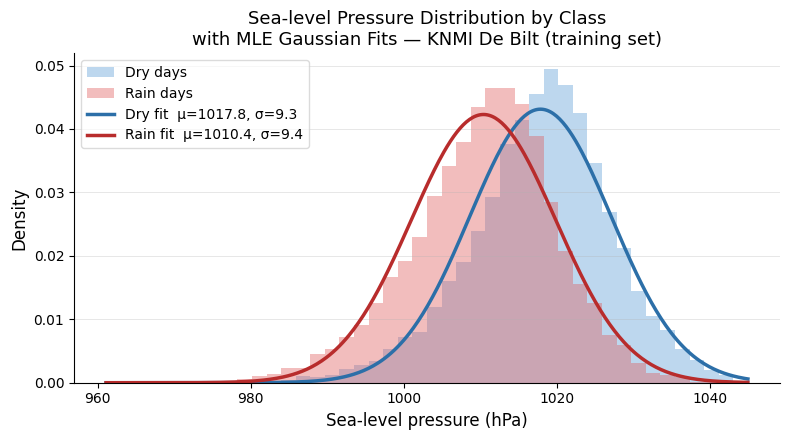

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fi = predictors.index("PG_hPa")
dry_v  = X_train[y_train==0, fi]
rain_v = X_train[y_train==1, fi]
dry_v  = dry_v[~np.isnan(dry_v)]
rain_v = rain_v[~np.isnan(rain_v)]

mn = min(dry_v.min(), rain_v.min())
mx = max(dry_v.max(), rain_v.max())
bins = np.linspace(mn, mx, 45)
xline = np.linspace(mn, mx, 400)

mu_d, std_d = dry_v.mean(),  dry_v.std()
mu_r, std_r = rain_v.mean(), rain_v.std()
gauss_d = (1/(std_d*np.sqrt(2*np.pi))) * np.exp(-0.5*((xline-mu_d)/std_d)**2)
gauss_r = (1/(std_r*np.sqrt(2*np.pi))) * np.exp(-0.5*((xline-mu_r)/std_r)**2)

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.hist(dry_v,  bins=bins, density=True, color="#5B9BD5", alpha=0.4, label="Dry days")
ax.hist(rain_v, bins=bins, density=True, color="#E05C5C", alpha=0.4, label="Rain days")
ax.plot(xline, gauss_d, color="#2c6fa8", linewidth=2.5, label=f"Dry fit  μ={mu_d:.1f}, σ={std_d:.1f}")
ax.plot(xline, gauss_r, color="#b82c2c", linewidth=2.5, label=f"Rain fit  μ={mu_r:.1f}, σ={std_r:.1f}")

ax.set_xlabel("Sea-level pressure (hPa)", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title("Sea-level Pressure Distribution by Class\nwith MLE Gaussian Fits — KNMI De Bilt (training set)", fontsize=13)
ax.legend(fontsize=10, framealpha=0.7)
ax.spines[["top","right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3, linewidth=0.7)

plt.tight_layout()
plt.savefig("pg_histogram.png", dpi=150)
plt.show()

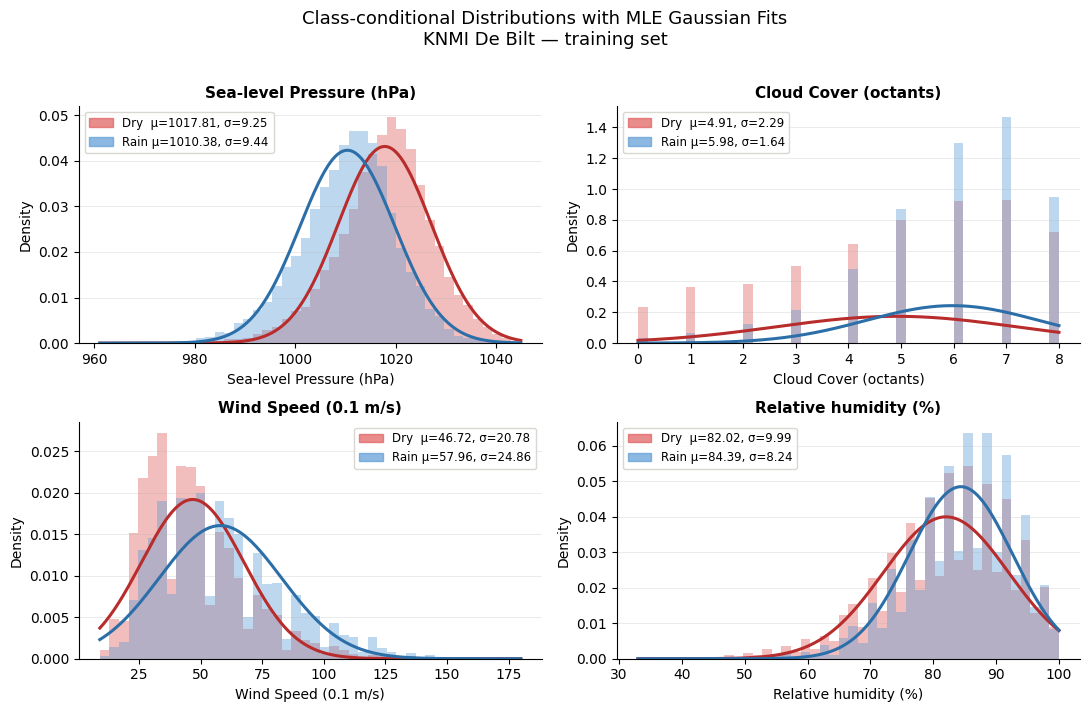

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

feats = ["PG_hPa", "NG", "FG", "UG"]
feat_labels = {
    "PG_hPa":    "Sea-level Pressure (hPa)",
    "NG":        "Cloud Cover (octants)",
    "FG":        "Wind Speed (0.1 m/s)",
    "UG":        "Relative humidity (%)"
}


fig, axes = plt.subplots(2, 2, figsize=(11, 7))
axes = axes.flatten()

for i, feat in enumerate(feats):
    ax = axes[i]
    fi = predictors.index(feat)
    dry_v  = X_train[y_train==0, fi]; dry_v  = dry_v[~np.isnan(dry_v)]
    rain_v = X_train[y_train==1, fi]; rain_v = rain_v[~np.isnan(rain_v)]

    bins  = np.linspace(min(dry_v.min(), rain_v.min()), max(dry_v.max(), rain_v.max()), 45)
    xline = np.linspace(bins[0], bins[-1], 400)

    mu_d, std_d = dry_v.mean(), dry_v.std()
    mu_r, std_r = rain_v.mean(), rain_v.std()
    gauss_d = (1/(std_d*np.sqrt(2*np.pi))) * np.exp(-0.5*((xline-mu_d)/std_d)**2)
    gauss_r = (1/(std_r*np.sqrt(2*np.pi))) * np.exp(-0.5*((xline-mu_r)/std_r)**2)

    ax.hist(dry_v,  bins=bins, density=True, color="#E05C5C", alpha=0.4)
    ax.hist(rain_v, bins=bins, density=True, color="#5B9BD5", alpha=0.4)
    ax.plot(xline, gauss_d, color="#b82c2c", linewidth=2.2)
    ax.plot(xline, gauss_r, color="#2c6fa8", linewidth=2.2)

    dry_patch  = mpatches.Patch(color="#E05C5C", alpha=0.7, label=f"Dry  μ={mu_d:.2f}, σ={std_d:.2f}")
    rain_patch = mpatches.Patch(color="#5B9BD5", alpha=0.7, label=f"Rain μ={mu_r:.2f}, σ={std_r:.2f}")
    ax.legend(handles=[dry_patch, rain_patch], fontsize=8.5, framealpha=0.85, edgecolor="#d4d1ca")

    ax.set_xlabel(feat_labels[feat], fontsize=10)
    ax.set_ylabel("Density", fontsize=10)
    ax.set_title(feat_labels[feat], fontsize=11, fontweight="bold", pad=6)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.25, linewidth=0.7)

fig.suptitle("Class-conditional Distributions with MLE Gaussian Fits\nKNMI De Bilt — training set", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("histograms_4panel.png", dpi=150, bbox_inches="tight")

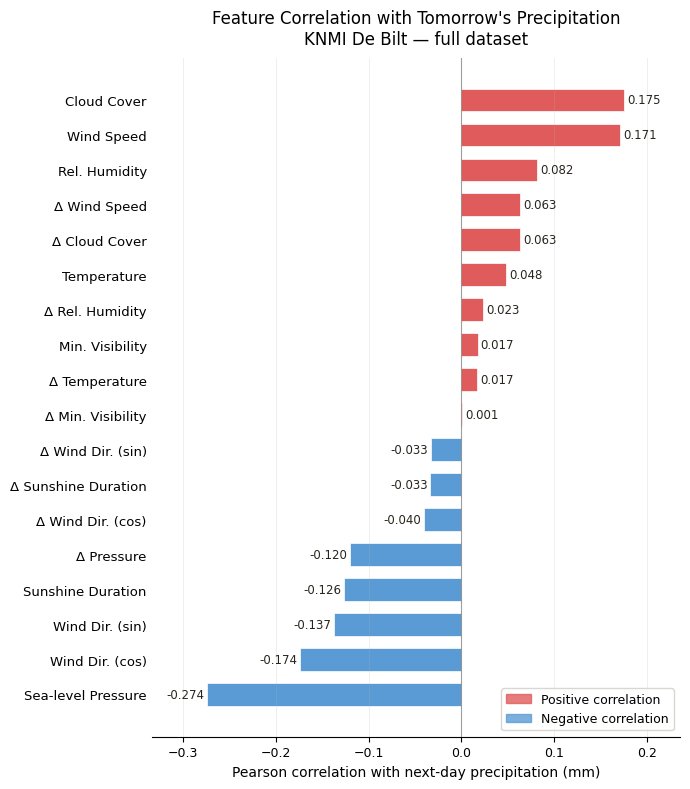

In [10]:
corr = df_features[predictors].corrwith(df_features["RH_mm_tomorrow"]).sort_values()

feat_labels = {
    "NG": "Cloud Cover", "UG": "Rel. Humidity", "PG_hPa": "Sea-level Pressure",
    "FG": "Wind Speed", "DDVEC_sin": "Wind Dir. (sin)", "DDVEC_cos": "Wind Dir. (cos)",
    "VVN": "Min. Visibility", "TG": "Temperature", "SQ": "Sunshine Duration",
    "dNG": "Δ Cloud Cover", "dUG": "Δ Rel. Humidity", "dPG_hPa": "Δ Pressure",
    "dFG": "Δ Wind Speed", "dDDVEC_sin": "Δ Wind Dir. (sin)", "dDDVEC_cos": "Δ Wind Dir. (cos)",
    "dVVN": "Δ Min. Visibility", "dTG": "Δ Temperature", "dSQ": "Δ Sunshine Duration"
}

labels = [feat_labels.get(f, f) for f in corr.index]
values = corr.values
colors = ["#E05C5C" if v > 0 else "#5B9BD5" for v in values]

fig, ax = plt.subplots(figsize=(7, 8))
bars = ax.barh(labels, values, color=colors, edgecolor="white", linewidth=0.5, height=0.65)

# Value labels
for bar, val in zip(bars, values):
    x = val + 0.003 if val >= 0 else val - 0.003
    ha = "left" if val >= 0 else "right"
    ax.text(x, bar.get_y() + bar.get_height()/2, f"{val:.3f}",
            va="center", ha=ha, fontsize=8.5, color="#28251d")

ax.axvline(0, color="#28251d", linewidth=0.8, alpha=0.4)
ax.set_xlabel("Pearson correlation with next-day precipitation (mm)", fontsize=10)
ax.set_title("Feature Correlation with Tomorrow's Precipitation\nKNMI De Bilt — full dataset", fontsize=12, pad=10)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", length=0, labelsize=9.5)
ax.tick_params(axis="x", labelsize=9)
ax.grid(axis="x", alpha=0.2, linewidth=0.7)
ax.set_xlim(values.min() - 0.06, values.max() + 0.06)

red_patch  = mpatches.Patch(color="#E05C5C", alpha=0.8, label="Positive correlation")
blue_patch = mpatches.Patch(color="#5B9BD5", alpha=0.8, label="Negative correlation")
ax.legend(handles=[red_patch, blue_patch], fontsize=9, loc="lower right", framealpha=0.85, edgecolor="#d4d1ca")

plt.tight_layout()
plt.savefig("pearson_correlation.png", dpi=150, bbox_inches="tight")
plt.show()